# Recover Transcriptomic Velocity in *C. elegans* Embryogenesis

CellDyc is applied to the AB lineage of C. elegans embryos (See details <span style="color: darkblue;">[here](datasets.rst#celldyc.datasets.core.celegans)</span>), where scRNA-seq profiles are mapped onto the invariant lineage tree and aligned with a high-resolution whole-embryo RNA-seq time series to estimate precise embryo time for individual cells. Each cell in the dataset represents a node on the lineage tree.

## Import Packages

In [2]:
import scanpy as sc
import matplotlib.pyplot as plt
import celldyc as cdc
from matplotlib.colors import Normalize
import matplotlib.cm as cm

## Load the Data
The analysis is based on in-built curated *C. elegans* AB lineage data. To run CellDyc analysis on your own data, read your file to an AnnData object with `adata = sc.read('path/file.h5ad')`.

This dataset contains cells from three time points (300, 400, and 500 minutes post-fertilization), each with precise embryo time annotations.

In [ ]:
# Load the curated C. elegans AB lineage 
adata = cdc.datasets.celegans()
adata

AnnData object with n_obs × n_vars = 333 × 20222
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cell', 'n.umi', 'time.point', 'batch', 'Size_Factor', 'cell.type', 'cell.subtype', 'plot.cell.type', 'raw.embryo.time', 'embryo.time', 'embryo.time.bin', 'raw.embryo.time.bin', 'lineage', 'passed_initial_QC_or_later_whitelisted', 'cell_generation'
    var: 'features', 'genes'
    uns: 'time.point_colors'
    obsm: 'X_umap'

First, we visualize the existing temporal annotations on the UMAP embedding. 
- Left Panel: Continuous "embryo time" as ground-truth reference.
- Right Panel: Discrete experimental sampling time points as training labels for CellDyc.

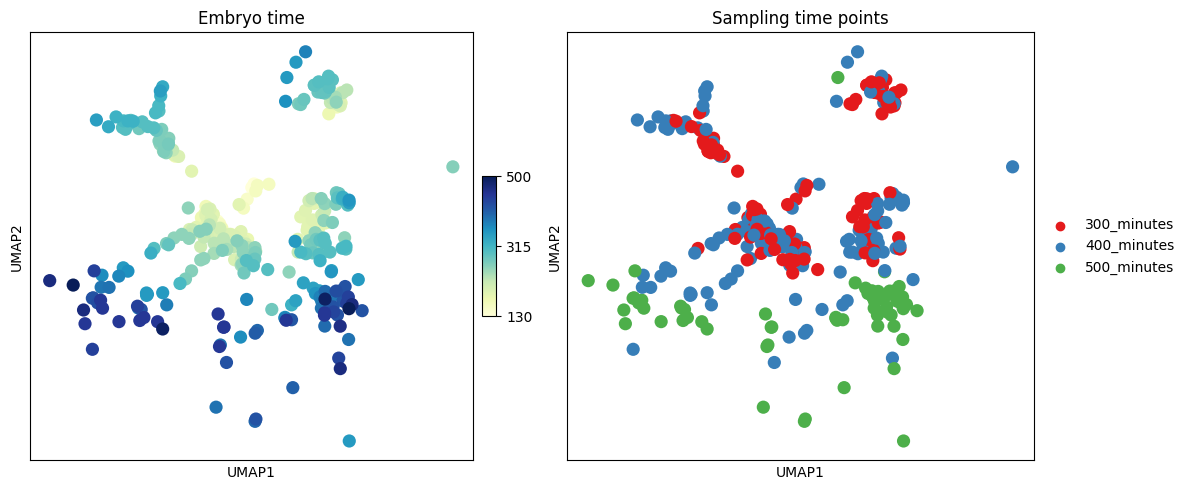

In [4]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# Plot continuous embryo time
sc.pl.umap(adata, color="embryo.time", cmap="YlGnBu",
          title="Embryo time", ax=axs[0], show=False)
axs[0].collections[0].colorbar.remove()

# Create custom colorbar for embryo time
norm = Normalize(vmin=adata.obs["embryo.time"].min(),
                 vmax=adata.obs["embryo.time"].max())
sm = cm.ScalarMappable(norm=norm, cmap="YlGnBu")
sm.set_array([])
cbar = fig.colorbar(sm, ax=axs[0], orientation="vertical",
                    fraction=0.03, pad=0.02, aspect=10, shrink=0.7,
                    ticks=[t_min:=(v:=adata.obs["embryo.time"]).min(),
                    (v.min()+v.max())/2,v.max()])

# Plot discrete sampling times
sc.pl.umap(adata, color="time.point",
           palette=["#e41a1c", "#377eb8", "#4daf4a"],
           title="Sampling time points", ax=axs[1], show=False)

plt.tight_layout()
plt.show()

## Preprocess the Data
Before applying CellDyc, the data undergoes standard preprocessing. The function `cdc.tl.preprocess` performs filtering, normalization, highly variable gene selection, PCA, and neighborhood graph construction.

Specifically, `cdc.tl.preprocess(adata, n_neighbors=40, n_pcs=20)` executes:
1. Filter genes detected in fewer than 10 cells
2. Normalize total counts per cell
3. Apply log1p transformation
4. Select top highly variable genes
5. Perform PCA dimensionality reduction
6. Construct k-nearest neighbor graph
   
which essentially runs the following:
1. *sc.pp.filter_genes(adata, min_cells=10)*
2. *sc.pp.normalize_total(adata, target_sum=1e4)*
3. *sc.pp.log1p(adata)*
4. *sc.pp.highly_variable_genes(adata, n_top_genes=2000)*
5. *adata = adata[:, adata.var.highly_variable].copy()*
6. *sc.tl.pca(adata, svd_solver="arpack")*
7. *sc.pp.neighbors(adata, n_neighbors=40, n_pcs=20)*

In [5]:
adata = cdc.tl.preprocess(adata, n_neighbors=40, n_pcs=20)
adata

AnnData object with n_obs × n_vars = 333 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cell', 'n.umi', 'time.point', 'batch', 'Size_Factor', 'cell.type', 'cell.subtype', 'plot.cell.type', 'raw.embryo.time', 'embryo.time', 'embryo.time.bin', 'raw.embryo.time.bin', 'lineage', 'passed_initial_QC_or_later_whitelisted', 'cell_generation'
    var: 'features', 'genes', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'time.point_colors', 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

We transform descriptive time point strings into numerical format.

In [6]:
cat_map = {'300_minutes': 300,
           '400_minutes': 400,
           '500_minutes': 500}
adata.obs['numerical_time'] = adata.obs['time.point'].map(cat_map).astype('category')

## Estimation of Transcriptomic Velocity
Transcriptomic velocity represent the transcriptome-wide time derivative of gene expression within individual cells. These velocities are learned through semi-supervised training using actual time points as supervisory labels. The time_key argument specifies which actual time points serve as training labels, while the time_weight parameter controls the relative weighting of the two loss components in the dual-loss training architecture. By default, predicted velocities are stored in **adata.layers['velocity']**.

In [7]:
cdc.tl.recover_dyc(adata, time_key="numerical_time", time_weight=0.01)

Training with early stop (max_epochs=500, patience=40)
epoch   1:loss=0.886128,trend_loss=0.878601,time_loss=0.752603
epoch  51:loss=0.200148,trend_loss=0.199435,time_loss=0.071356
epoch 101:loss=0.121064,trend_loss=0.120555,time_loss=0.050872
epoch 151:loss=0.105269,trend_loss=0.104800,time_loss=0.046911
epoch 201:loss=0.093951,trend_loss=0.093566,time_loss=0.038456
epoch 251:loss=0.089584,trend_loss=0.089295,time_loss=0.028932
Early stopping at epoch 280


AnnData object with n_obs × n_vars = 333 × 2000
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'cell', 'n.umi', 'time.point', 'batch', 'Size_Factor', 'cell.type', 'cell.subtype', 'plot.cell.type', 'raw.embryo.time', 'embryo.time', 'embryo.time.bin', 'raw.embryo.time.bin', 'lineage', 'passed_initial_QC_or_later_whitelisted', 'cell_generation', 'numerical_time', 'getime'
    var: 'features', 'genes', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'getime_weights'
    uns: 'time.point_colors', 'log1p', 'hvg', 'pca', 'neighbors'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'velocity'
    obsp: 'distances', 'connectivities'

## Projection of Velocities
The velocities are then projected onto the embedding specified by the basis and colored according to the color. In this dataset, we use embryo time as the ground-truth temporal reference for coloring the embedding. The **plot_velocity_projection** function serves as a wrapper that encapsulates calls to scVelo's velocity_graph and velocity_embedding_stream functions.

  0%|          | 0/333 [00:00<?, ?cells/s]

computing velocity graph
finished.


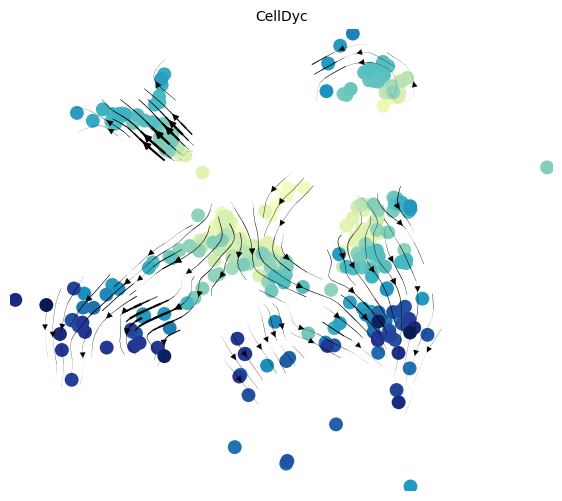

computing velocity embedding
finished.


In [8]:
cdc.pl.plot_velocity_projection(adata, color='embryo.time', size=400, cmap='YlGnBu',
                                 alpha=1,title="CellDyc",figsize=(7,6),colorbar=False)


## Estimation of Time Representation
The inferred gene-embedded time aligns with the provided sampling times. By default, predicted time values are stored in **adata.obs['getime']**.

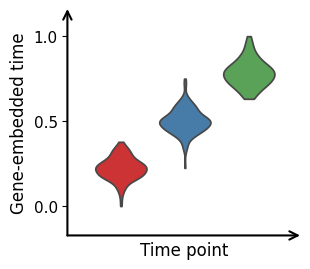

<Axes: xlabel='Time point', ylabel='Gene-embedded time'>

In [9]:
palette=["#e41a1c", "#377eb8", "#4daf4a"]
cdc.pl.getime_violin(adata, 'getime', 'numerical_time',palette=palette)